# matplotlib 的基本方法

| 方法名 | 说明 |
|:---|:---|
|`title()`|设置图表名称|
|`xlael`||
|||
|||

### 题目 1
绘制任意曲线图,要求如下:  
1.显示图形名称  
2.为x 轴和y 轴定义说明信息  
3.使用中文显示，处理符号显示问题  

In [ ]:
import matplotlib.pyplot as plt
import numpy as np 

def main() -> None:
    
    # 设置中文
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    # 描点画图
    x = np.arange(0, 50)
    y = x ** 3
    plt.xlabel("立方体的边长")
    plt.ylabel("立方体的体积")
    plt.plot(x, y)
    plt.grid()
    plt.title("立方体体积随边长变化的图像")
    
if __name__ == "__main__":
    main()

### 题目2
已知数据为2000 年到2020 年20 年之间的销量情况.  
```Python
sales = [109, 150, 172, 260, 273, 333, 347, 393, 402, 446, 466, 481, 499,504, 513, 563, 815, 900,
930, 961]
```  
要求:  
1.绘制年度销量线形图.x 轴为年份,y 轴为销量。  
2.显示图例  

In [ ]:
import matplotlib.pyplot as plt

def main() -> None:
    
    # 设置中文
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False

    sales = [109, 150, 172, 260, 273, 333, 347, 393, 402, 446, 466, 481, 499,504, 513, 563, 815, 900,
    930, 961]
    years = range(2000, 2020)
    plt.title("2000-2020年年度销量情况图")
    plt.xlabel("年份")
    plt.ylabel("销量")
    # 设置 X 轴的刻度，确保只显示整数年份
    # rotation=45 让标签倾斜，避免重叠
    plt.xticks(years, rotation=45)
    plt.plot(years, sales, marker = 'o', linestyle = '-')

if __name__ == "__main__":
    main()

### 题目 3
根据下表数据绘制图形  
读取data1.csv 文件  
1. 绘制这三部电影在这三天内票房的柱状图。
2. 绘制这三部电影在这三天内票房的堆叠图。
3. 绘制第三天每部电影票房占比的饼状图。
4. 绘制第三天每部电影票房趋势折线图。
### 题目 4
绘制子图  
1. 在一个图形对象中创建2*2 的4 个区域, 分别显示上题四个图。
2. 分别设置四个区域图形的名称等参数，使得图形清晰美观。
3. 将图片保存到当前目录文件名为analysis.png

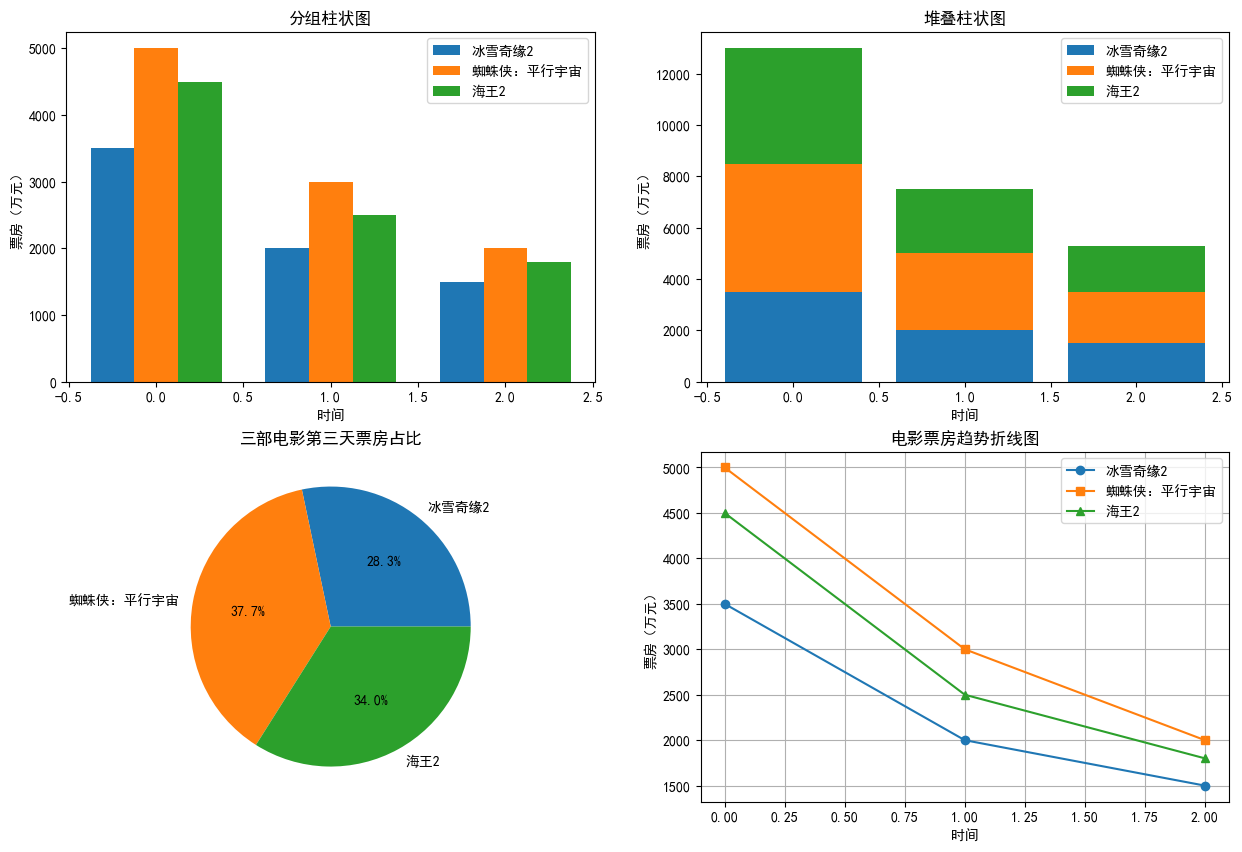

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import csv

def main() -> None:
    plt.rcParams['font.sans-serif'] = ['SimHei'] 
    plt.rcParams['axes.unicode_minus'] = False
    
    with open("data1.csv", encoding="utf-8") as file:
        reader = csv.reader(file)
        name = next(reader)
        rows = list(reader)
    
    #创建空列表储存票房数据    
    movie1 = []
    movie2 = []
    movie3 = []
    
    for row in rows:
        movie1.append(int(row[1])) # csv.reader() 读取的所有数据默认都是字符串类型
        movie2.append(int(row[2])) # 使用 int() 实现 string -> int
        movie3.append(int(row[3]))
    
    # 转换为 numpy 数组，方便总票房的添加
    m1 = np.array(movie1)
    m2 = np.array(movie2)
    m3 = np.array(movie3)
    
    x = np.arange(len(movie1))
    width = 0.25
    
    # 均等划分 2*2 画布
    fig, ax = plt.subplots(2, 2, figsize=(15, 10))
    
    # (1) 分组柱状图
    ax1 = ax[0, 0]
    ax1.bar(x - width, m1, width=width, label=name[1])
    ax1.bar(x, m2, width=width, label=name[2])
    ax1.bar(x + width, m3, width=width, label=name[3])
    ax1.set_title("分组柱状图")
    ax1.set_xlabel("时间")
    ax1.set_ylabel("票房（万元）")
    ax1.legend()
    
    # (2) 堆叠柱状图
    ax2 = ax[0, 1]
    ax2.bar(x, m1, label=name[1])
    ax2.bar(x, m2, bottom=m1, label=name[2])
    ax2.bar(x, m3, bottom=m1 + m2, label=name[3])
    ax2.set_title("堆叠柱状图")
    ax2.set_xlabel("时间")
    ax2.set_ylabel("票房（万元）")
    ax2.legend()

    # (3) 饼状图
    ax3 = ax[1, 0]
    # 创建列表取第三天的数据
    pie_data = [m1[2], m2[2], m3[2]]
    pie_labels = [name[1], name[2], name[3]]
    # 绘制饼状图
    ax3.pie(pie_data, labels=pie_labels, autopct='%1.1f%%')
    ax3.set_title('三部电影第三天票房占比')
    
    # (4) 折线图
    ax4 = ax[1, 1]
    ax4.plot(x, m1, label=name[1], marker='o')
    ax4.plot(x, m2, label=name[2], marker='s')
    ax4.plot(x, m3, label=name[3], marker='^')
    ax4.set_title('电影票房趋势折线图')
    ax4.set_xlabel('时间')
    ax4.set_ylabel('票房（万元）')
    ax4.grid(True)
    ax4.legend()
    
    plt.savefig('analysis.png')  
    plt.show()
    
if __name__ == "__main__":
    main()
    
    
    
    

根据对话记录,你遇到的具体问题总结如下:

## **问题清单:**

### **1. CSV 数据读取相关**
- ❓ `csv.reader()` 返回的 `reader` 对象是什么,有什么作用
- ❓ `list(reader)` 之后的列表元素类型是否一定是字符串
- ❓ 票房数据不进行类型转换(`int()`)是否可以

### **2. NumPy 使用相关**
- ❓ 为什么一定要使用 NumPy 库
- ❓ `np.arange()` 函数的作用是什么
- ❓ `x = np.arange(len(movie1))` 在代码中的全局作用

### **3. 绘图参数理解**
- ❓ `width` 参数的设置规则和讲究
- ❓ `figsize` 参数的含义和单位
- ❓ `plt.subplots(2, 2, figsize=(15, 10))` 的作用
- ❓ `bar()` 函数接受哪些参数
- ❓ `autopct` 参数涉及哪些英文单词

### **4. 横坐标设置**
- ❓ 如何将横坐标设置为"第某天"的格式

### **5. 代码错误**
- ⚠️ 代码中存在 bug:
  ```python
  movie2.append(int(row[1]))  # 错误,应该是 row[2]
  movie3.append(int(row[1]))  # 错误,应该是 row[3]
  ```

## **核心问题:**
你主要在学习 **matplotlib 数据可视化**,对以下内容不太熟悉:
- CSV 数据读取和类型转换
- NumPy 数组的必要性和基本操作
- matplotlib 子图布局和参数设置
- 各种图表类型的绘制方法(柱状图、堆叠图、饼图、折线图)